In [16]:
import joblib
from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd
from scipy.interpolate import pchip_interpolate

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import minmax_scale
import seaborn as sns


plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'

In [17]:
import joblib
from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd
from scipy.interpolate import pchip_interpolate

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import minmax_scale
import seaborn as sns
from wordcloud import WordCloud

plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'

# Introduction
# Settings

In [18]:
DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')
PLOT_PATH = Path('../plots')

# colors =
N_CLUSTER_LIST = list(range(2, 7))
RED, YELLOW, BLUE = '#c00000', '#dcd844', '#0033cc'

PLOT_PARAMS = dict(bbox_inches='tight', transparent=True, dpi=600)

RED, YELLOW, BLUE, ORANGE, GREEN, GOLD = ('#c00000', '#dcd844', '#0033cc', '#FF5733', '#4CAF50', '#FFD700')
DARK_RED, DARK_YELLOW, DARK_BLUE, = ['#8b0000', '#e6af00', '#002699', ]

In [19]:
DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')
PLOT_PATH = Path('../plots')

# colors =
N_CLUSTER_LIST = list(range(2, 7))
RED, YELLOW, BLUE = '#c00000', '#dcd844', '#0033cc'

PLOT_PARAMS = dict(bbox_inches='tight', transparent=True, dpi=600)

RED, YELLOW, BLUE, ORANGE, GREEN, GOLD = ('#c00000', '#dcd844', '#0033cc', '#FF5733', '#4CAF50', '#FFD700')
DARK_RED, DARK_YELLOW, DARK_BLUE, = ['#8b0000', '#e6af00', '#002699', ]

# Plots

## inhouse_age_18_30_resting transform

In [24]:
# load plot data
name = 'inhouse_age_18_30_resting'
plot_data = pd.read_csv(RESULTS_PATH / f'neurosynth_decode/{name}_top15_terms.csv', index_col=0)
order = ['decision making', 'value', 'reward',
         'self',  'social', 'autobiographical','theory mind', 'person',
         'depression','emotion','affective',   'fear',
         'food','motivation','choice', ]
plot_data = plot_data.reindex(order)
sum_series = plot_data.sum(axis=1)
for col in plot_data.columns:
    plot_data[col] /= sum_series

#
social_list = plot_data['social'].values
emotion_list = plot_data['emotion'].values
valuation_list = plot_data['valuation'].values

social_list = np.concatenate((social_list, [social_list[0]]))
emotion_list = np.concatenate((emotion_list, [emotion_list[0]]))
valuation_list = np.concatenate((valuation_list, [valuation_list[0]]))

categories = [x.title() for x in plot_data.index]
num_vars = len(categories)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

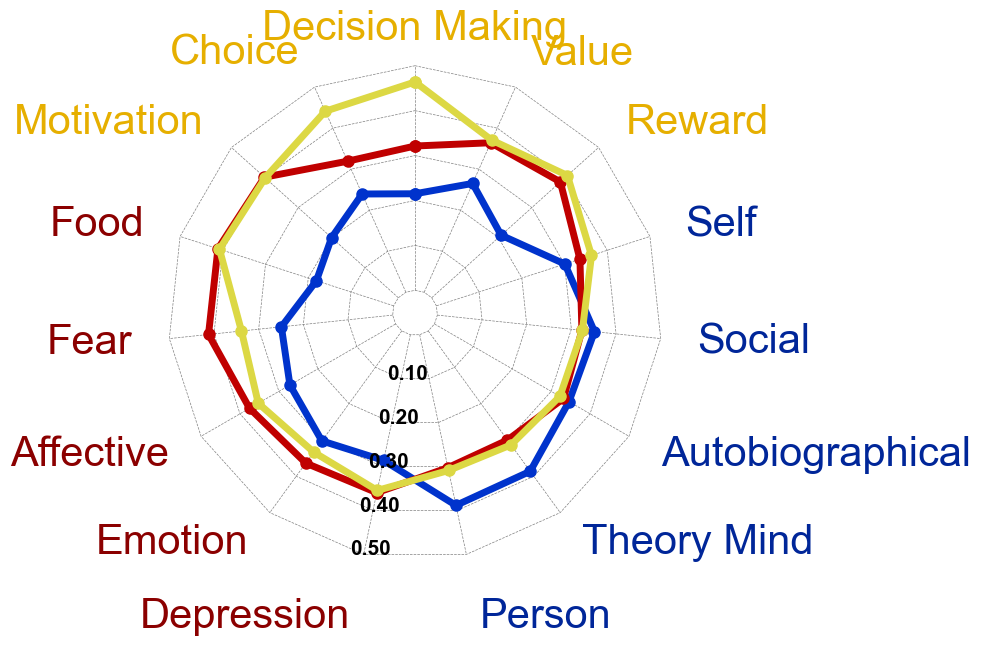

In [25]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True, ))
ax.grid(False)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.spines['polar'].set_visible(False)

# plot background grid
y_ticks = np.arange(0, 0.51, 0.1)
x_ticks = angles[:-1]
background_line_params = dict(color="grey", linewidth=0.5, linestyle="dashed", zorder=1)
for y in y_ticks:
    ax.plot(angles, [y] * len(angles), **background_line_params)
for x in x_ticks:
    ax.plot([x] * len(y_ticks), y_ticks, **background_line_params)

# plot data
line_params = dict(marker='.', linewidth=5, linestyle='solid', markersize=16, zorder=2)





ax.plot(angles, social_list, label='Social', color=BLUE, **line_params)
ax.plot(angles, emotion_list, label='Emotion', color=RED, **line_params)
ax.plot(angles, valuation_list, label='Reward', color=YELLOW, **line_params)

# set up x ticks
ax.set_xticks(x_ticks)
ax.tick_params(axis='x', pad=0)
ax.set_xticklabels(categories, fontsize=30)
alignment_list = ['center'] + ['left'] * 7 + ['right'] * 7
color_list = [DARK_YELLOW] * 3 + [DARK_BLUE] * 5 + [DARK_RED] * 5 + [DARK_YELLOW] * 2
for i, x_tick_label in enumerate(ax.get_xticklabels()):
    x_tick_label.set_horizontalalignment(alignment_list[i])
    x_tick_label.set_color(color_list[i])
    if (i == 7) or (i == 8):
        x_tick_label.set_y(-0.1)

# set up y ticks
ax.set_ylim(-0.05, 0.55)
ax.set_yticklabels([])
annotation_params = dict(xytext=(5, 5), textcoords='offset points', ha='center', va='center',
                         fontweight='bold', fontsize=15, zorder=4, )
for y in y_ticks[1:]:
    ax.annotate(text=f'{y:.2f}', xy=(angles[8], y + 0.005), **annotation_params)

fig.savefig(PLOT_PATH / f'radar_plot_{name}_Norm.svg', **PLOT_PARAMS)
fig.savefig(PLOT_PATH / f'radar_plot_{name}_Norm.png', **PLOT_PARAMS)
plt.show()

ax.set_xticklabels([], fontsize=30)
fig.savefig(PLOT_PATH / f'radar_plot_{name}_Norm_NoLabels.svg', **PLOT_PARAMS)
fig.savefig(PLOT_PATH / f'radar_plot_{name}_Norm_NoLabels.png', **PLOT_PARAMS)